In [32]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions # Corrected import
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential # Corrected import (model -> models)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [33]:
X,y = make_circles(n_samples =100 ,noise =0.1 ,random_state =1)

<Axes: >

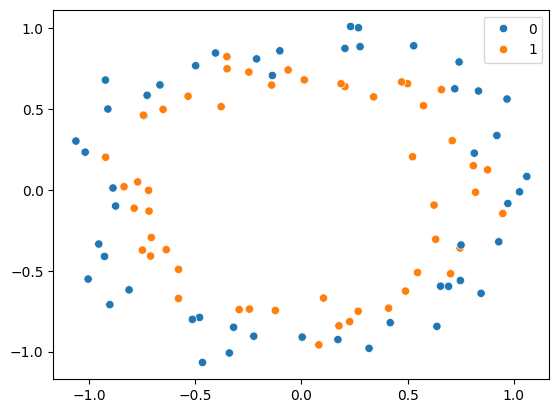

In [34]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=1)

In [6]:
model=Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [9]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=3500)

Streaming output truncated to the last 5000 lines.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9234 - loss: 0.1979 - val_accuracy: 0.8500 - val_loss: 0.5110
Epoch 1002/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9117 - loss: 0.2213 - val_accuracy: 0.8500 - val_loss: 0.5108
Epoch 1003/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9391 - loss: 0.1849 - val_accuracy: 0.8500 - val_loss: 0.5112
Epoch 1004/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9195 - loss: 0.2107 - val_accuracy: 0.8500 - val_loss: 0.5124
Epoch 1005/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9547 - loss: 0.1549 - val_accuracy: 0.8500 - val_loss: 0.5135
Epoch 1006/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9133 - loss: 0.1892 - val_accuracy: 0.8500 - val_loss: 0.5193
Epoch 1007/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8914 - loss: 0.2181 - val_accuracy: 0.8500 - val_loss: 0.5186
Epoch 1008/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step -

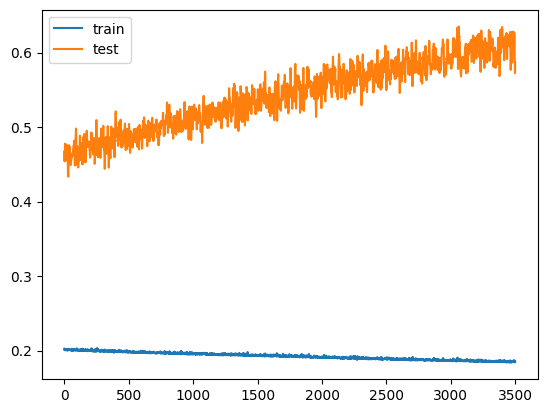

In [12]:
plt.plot(history.history['loss'],label ='train')
plt.plot(history.history['val_loss'],label ='test')
plt.legend()
plt.show()

call backs sy murad hai ky hr epoch ky bt hm ruk kr kuch na kuch kam krwa skth hain ,or hm is may  earlystoppping ka concept use kraingy ky hr epoch ky bhd hmay koi faida h0 b rha hai yn nhi

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


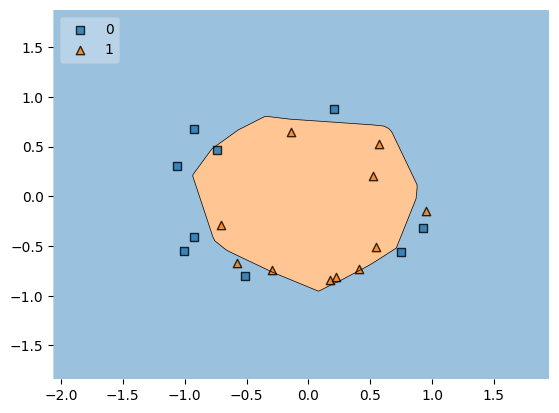

In [13]:
plot_decision_regions(X_test,y_test.ravel(),clf =model,legend=2)
plt.show()

## EarlyStopping

In [52]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [53]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [54]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [55]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.4250 - loss: 0.6982 - val_accuracy: 0.5500 - val_loss: 0.6933
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5414 - loss: 0.6876 - val_accuracy: 0.4500 - val_loss: 0.6993
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5117 - loss: 0.6868 - val_accuracy: 0.4000 - val_loss: 0.7055
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5133 - loss: 0.6903 - val_accuracy: 0.4000 - val_loss: 0.7105
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5203 - loss: 0.6847 - val_accuracy: 0.3500 - val_loss: 0.7162
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5367 - loss: 0.6839 - val_accuracy: 0.3500 - val_loss: 0.7207
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5211 - loss: 0.6835 - val_accuracy: 0.3000 - val_loss: 0.7246
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5625 - loss: 0.6811 - val_accuracy: 0.3000 - 

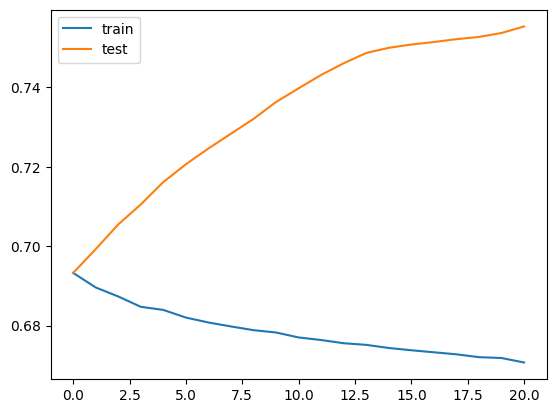

In [58]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


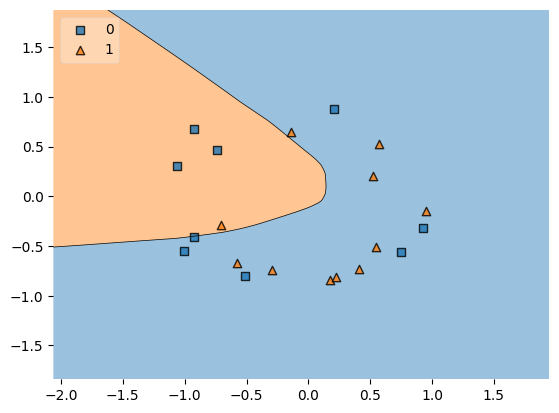

In [57]:
plot_decision_regions(X_test,y_test.ravel(),clf=model,legend=2)
plt.show()